<h3  style = "color: skyblue" >Importing Libraries<h3>

In [1]:
import time
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
from torch import optim
from torchvision import transforms, datasets
from torch.utils.data import random_split, DataLoader

<h3 style = "color: skyblue" >GPU Acceleration</h3>

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


<h3  style = "color: skyblue" >Data Ingestion and Transformation<h3>

In [3]:
dataset_path = "../data"

transform = transforms.Compose([

    #Data Augmentation
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),

    #Normal Transformation
    transforms.Resize(size=(224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

])

dataset = datasets.ImageFolder(root= dataset_path, transform= transform)

<h3 style = "color:skyblue" >Data Overview</h3>

In [4]:
print(f"The Size of Dataset: {len(dataset)}")
print(f"The number of classes: {len(dataset.classes)}")
print("==" * 15)
print("\nThe Classes:")
class_name = dataset.classes
print(class_name)

The Size of Dataset: 200000
The number of classes: 2

The Classes:
['ai', 'real']


In [5]:
dataset.class_to_idx

{'ai': 0, 'real': 1}

<h3 style = "color:skyblue" >Data Splitting</h3>

In [6]:
train_size = int(len(dataset) * 0.75)
val_size  = int(len(dataset) - train_size)

train_size, val_size

(150000, 50000)

In [7]:
train_dataset, val_dataset = random_split(dataset= dataset, lengths=[train_size, val_size])

print("After Random Splitting:\n")
print(f"Train size: {len(train_dataset)}")
print(f"Validation size: {len(val_dataset)}")

After Random Splitting:

Train size: 150000
Validation size: 50000


<h3 style = "color:skyblue" >Batching</h3>

In [8]:
batch_size = 32

train_loader = DataLoader(dataset= train_dataset, batch_size= batch_size, shuffle= True)

val_loader = DataLoader(dataset= val_dataset, batch_size= batch_size, shuffle= True)

In [9]:
for images, labels in train_loader:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [10]:
images[0].shape

torch.Size([3, 224, 224])

In [11]:
labels[0]

tensor(0)

<h3 style = "color:skyblue" >Visualizing  One Image</h3>

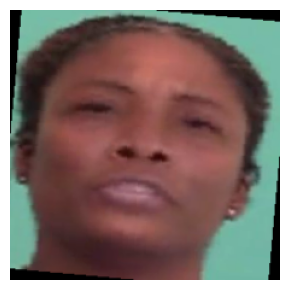

In [12]:
# Take one image from batch (C, H, W):
img = images[0]

# Convert to (H, W, C)
img = img.permute(1, 2, 0)

# Unnormalize
mean = torch.tensor([0.485, 0.456, 0.406])
std  = torch.tensor([0.229, 0.224, 0.225])

img = img * std + mean

# Clip to valid range
img = img.clamp(0, 1)

# Plot
plt.figure(figsize=(3, 3))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()


<h3 style = "color:skyblue" >Modelling</h3>

In [ ]:
class DeepFakeClassifierCNN(nn.Module):

    def __init__(self, num_classes= 1):
        super().__init__()

        self.conv_layers = nn.Sequential(

            nn.Conv2d(in_channels=3, out_channels= 32, kernel_size=(3,3), stride=1, padding= 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2), stride=2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(3,3), stride=1, padding= 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2), stride=2),

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=(3,3), stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2), stride=2)

        )


        self.fc_layers = nn.Sequential(

            nn.Flatten(),
            nn.Linear(in_features=(128 * 28 * 28), out_features= 500),
            nn.ReLU(),
            nn.Linear(in_features=500, out_features= num_classes)
        )

    
    def forward(self, x):

        x = self.conv_layers(x)
        x = self.fc_layers(x)

        return x


In [14]:
#Instantiate the model, Loss function, and optimizer
model = DeepFakeClassifierCNN(num_classes=1).to(device= device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(params= model.parameters(), lr= 0.001)

In [15]:
def train_model(model, criterion, optimizer, epochs = 5):

    start = time.time()

    for epoch in range(epochs):
        #Training
        model.train()
        running_loss = 0.0

        for batch_num, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            #Zero the previous additive grads
            optimizer.zero_grad()

            #Forward Prop
            outputs = model.forward(images)
            loss = criterion(outputs.squeeze(1).float(), labels.float())

            #Backward Prop and update parameters
            loss.backward()
            optimizer.step()

            if (batch_num + 1) % 1000 == 0:
                print(f"Batch: {batch_num +1} - Epoch: {epoch + 1} - Loss: {loss.item(): 0.2f}")

            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        print(f"Epoch[{epoch + 1}/ {epochs}] - Avg Loss: {epoch_loss:0.4f}")


        #Validation
        model.eval()
        correct = 0
        total = 0
        all_labels, all_predictions = [], []

        with torch.inference_mode():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model.forward(images)
                _, predicted = torch.max(outputs.data, 1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(predicted.cpu().numpy())

            print(f"*** Validation Accuracy: {100 * correct / total : 0.2f}% ***")

    end = time.time()
    print(f"Execution time: {end - start} seconds") 


    return all_labels, all_predictions

In [16]:
all_labels, all_predictions = train_model(model, criterion, optimizer, epochs= 5)

Batch: 1000 - Epoch: 1 - Loss:  0.62
Batch: 2000 - Epoch: 1 - Loss:  0.64
Batch: 3000 - Epoch: 1 - Loss:  0.58
Batch: 4000 - Epoch: 1 - Loss:  0.56
Epoch[1/ 5] - Avg Loss: 0.5544
*** Validation Accuracy:  49.97% ***
Batch: 1000 - Epoch: 2 - Loss:  0.39
Batch: 2000 - Epoch: 2 - Loss:  0.43
Batch: 3000 - Epoch: 2 - Loss:  0.48
Batch: 4000 - Epoch: 2 - Loss:  0.41
Epoch[2/ 5] - Avg Loss: 0.4037
*** Validation Accuracy:  49.97% ***
Batch: 1000 - Epoch: 3 - Loss:  0.26
Batch: 2000 - Epoch: 3 - Loss:  0.19
Batch: 3000 - Epoch: 3 - Loss:  0.45
Batch: 4000 - Epoch: 3 - Loss:  0.33
Epoch[3/ 5] - Avg Loss: 0.3320
*** Validation Accuracy:  49.97% ***
Batch: 1000 - Epoch: 4 - Loss:  0.37
Batch: 2000 - Epoch: 4 - Loss:  0.26
Batch: 3000 - Epoch: 4 - Loss:  0.51
Batch: 4000 - Epoch: 4 - Loss:  0.27
Epoch[4/ 5] - Avg Loss: 0.2858
*** Validation Accuracy:  49.97% ***
Batch: 1000 - Epoch: 5 - Loss:  0.20
Batch: 2000 - Epoch: 5 - Loss:  0.13
Batch: 3000 - Epoch: 5 - Loss:  0.37
Batch: 4000 - Epoch: 5 - 